In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from scipy import stats
import matplotlib.pyplot as plt
import warnings
import os
import matplotlib.dates as mdates 
import matplotlib as mpl
warnings.filterwarnings("ignore")
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['font.size'] = 12

### MP

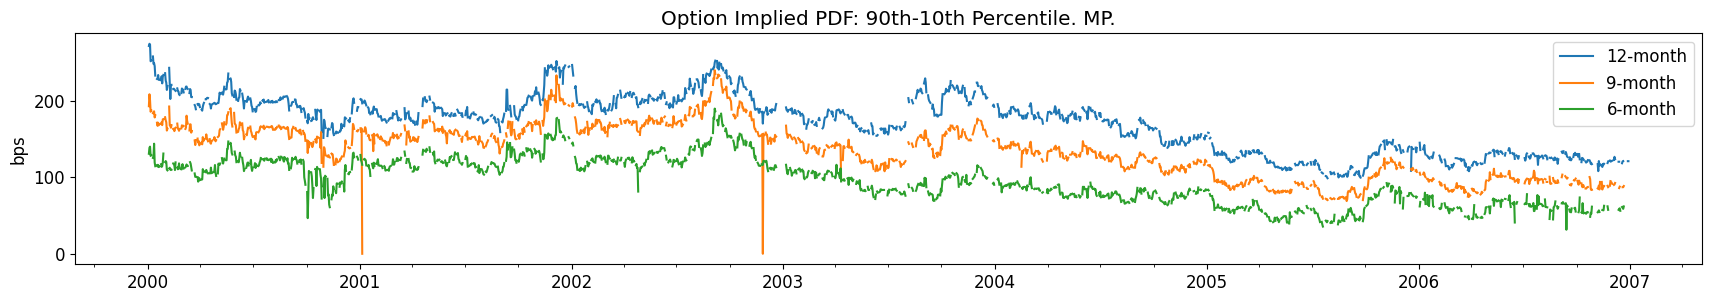

In [2]:
data_path = r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\RiskNeutralDensities\Densities\12_month\Uncertainty_Rates_MP_12month.pkl'
indicator_MP_12 = pd.read_pickle(data_path)
indicator_MP_12.loc[indicator_MP_12.pdf_width == 0] = np.nan
indicator_MP_12.dropna(inplace=True)
date_index = pd.date_range(start='1/1/2000', end='31/12/2006',freq='D')
indicator_MP_12 = indicator_MP_12.reindex(date_index)

data_path = r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\RiskNeutralDensities\Densities\9_month\Uncertainty_Rates_MP_9month.pkl'
indicator_MP_9 = pd.read_pickle(data_path)
indicator_MP_9.loc[indicator_MP_9.pdf_width == 0] = np.nan
indicator_MP_9.dropna(inplace=True)
date_index = pd.date_range(start='1/1/2000', end='31/12/2006',freq='D')
indicator_MP_9 = indicator_MP_9.reindex(date_index)

data_path = r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\RiskNeutralDensities\Densities\6_month\Uncertainty_Rates_MP_6month.pkl'
indicator_MP_6 = pd.read_pickle(data_path)
indicator_MP_6.loc[indicator_MP_6.pdf_width == 0] = np.nan
indicator_MP_6.dropna(inplace=True)
date_index = pd.date_range(start='1/1/2000', end='31/12/2006',freq='D')
indicator_MP_6 = indicator_MP_6.reindex(date_index)
                                  
month = mdates.MonthLocator(range(1,13,3)) 
year = mdates.YearLocator()
fmt = mdates.DateFormatter('%Y')

fig,ax = plt.subplots(1,1,figsize=(21,3))
ax.plot(indicator_MP_12.index,indicator_MP_12.pdf_width,label='12-month')
ax.plot(indicator_MP_9.index,indicator_MP_9.pdf_width,label='9-month')
ax.plot(indicator_MP_6.index,indicator_MP_6.pdf_width,label='6-month')
ax.legend()
ax.xaxis.set_major_locator(year)
ax.xaxis.set_minor_locator(month)
ax.xaxis.set_major_formatter(fmt)

ax.set_title('Option Implied PDF: 90th-10th Percentile. MP.')
ax.set_ylabel('bps')
plt.show()

### LEI

In [3]:
data_path = r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\RiskNeutralDensities\Densities\12_month\Uncertainty_Rates_LEI_12month.pkl'
indicator_LEI_12 = pd.read_pickle(data_path)
indicator_LEI_12.loc[indicator_LEI_12.pdf_width == 0] = np.nan
indicator_LEI_12.dropna(inplace=True)
date_index = pd.date_range(start='1/1/2007', end='21/01/2025',freq='D')
indicator_LEI_12 = indicator_LEI_12.reindex(date_index)

data_path = r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\RiskNeutralDensities\Densities\9_month\Uncertainty_Rates_LEI_9month.pkl'
indicator_LEI_9 = pd.read_pickle(data_path)
indicator_LEI_9.loc[indicator_LEI_9.pdf_width == 0] = np.nan
indicator_LEI_9.dropna(inplace=True)
date_index = pd.date_range(start='1/1/2007', end='21/01/2025',freq='D')
indicator_LEI_9 = indicator_LEI_9.reindex(date_index)

data_path = r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\RiskNeutralDensities\Densities\6_month\Uncertainty_Rates_LEI_6month.pkl'
indicator_LEI_6 = pd.read_pickle(data_path)
indicator_LEI_6.loc[indicator_LEI_6.pdf_width == 0] = np.nan
indicator_LEI_6.dropna(inplace=True)
date_index = pd.date_range(start='1/1/2007', end='21/01/2025',freq='D')
indicator_LEI_6 = indicator_LEI_6.reindex(date_index)

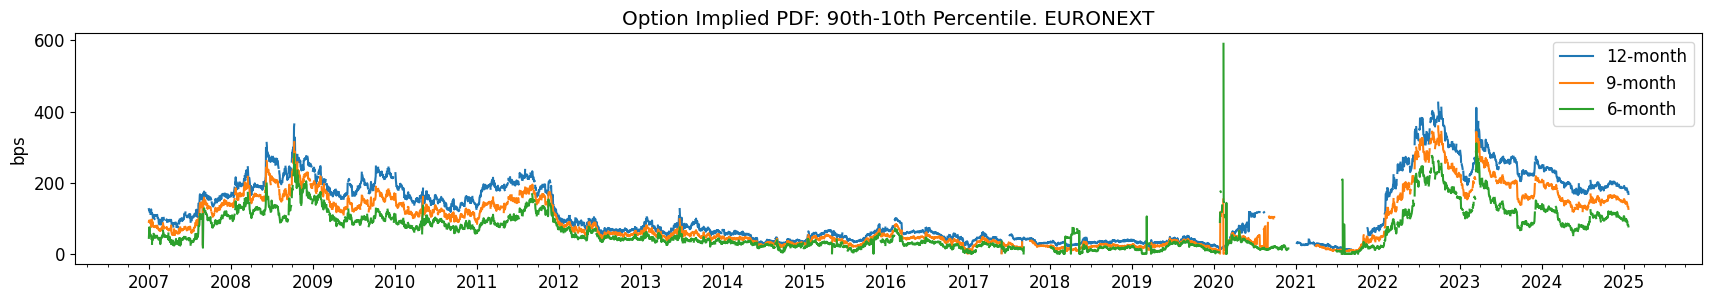

In [4]:
month = mdates.MonthLocator(range(1,13,3)) 
year = mdates.YearLocator()
fmt = mdates.DateFormatter('%Y')

fig,ax = plt.subplots(1,1,figsize=(21,3))
ax.plot(indicator_LEI_12.index,indicator_LEI_12.pdf_width,label='12-month')
ax.plot(indicator_LEI_9.index,indicator_LEI_9.pdf_width,label='9-month')
ax.plot(indicator_LEI_6.index,indicator_LEI_6.pdf_width,label='6-month')
ax.legend()
ax.xaxis.set_major_locator(year)
ax.xaxis.set_minor_locator(month)
ax.xaxis.set_major_formatter(fmt)

ax.set_title('Option Implied PDF: 90th-10th Percentile. EURONEXT')
ax.set_ylabel('bps')
plt.show()

### Uncertainty Indicator with 12-month

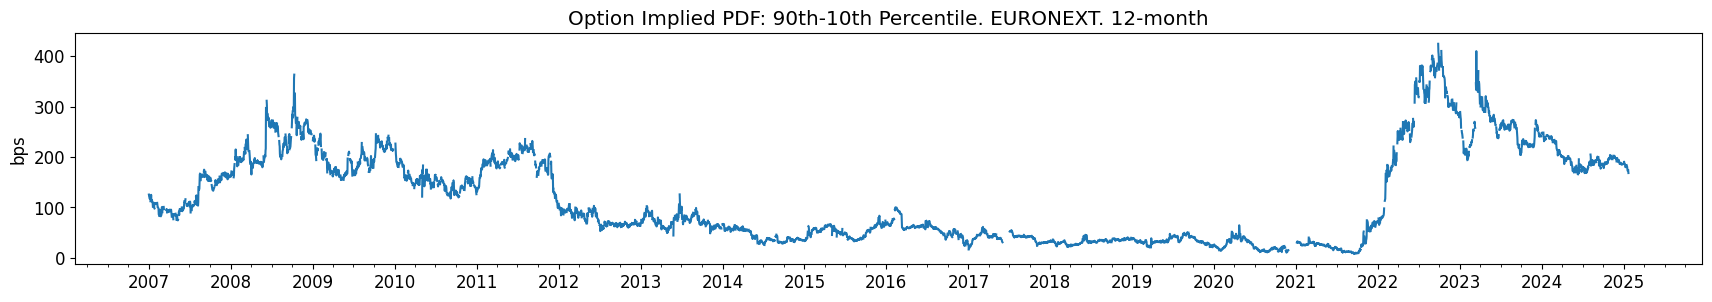

In [5]:
# # Outlier in 2018
# maxx = np.argmax(indicator_LEI_12.loc[datetime(2018,1,1):datetime(2018,12,31)].pdf_width)
# indicator_LEI_12.loc[datetime(2018,1,1):datetime(2018,12,31)].iloc[maxx].pdf_width = np.nan

# # Outlier in 2017
minn = np.argmin(indicator_LEI_12.loc[datetime(2017,6,1):datetime(2017,9,1)].pdf_width)
indicator_LEI_12.loc[datetime(2017,6,1):datetime(2017,9,1)].iloc[minn].pdf_width = np.nan 
minn = np.argmin(indicator_LEI_12.loc[datetime(2017,3,1):datetime(2017,6,1)].pdf_width)
indicator_LEI_12.loc[datetime(2017,3,1):datetime(2017,6,1)].iloc[minn].pdf_width = np.nan 
# minn = np.argmin(indicator_LEI_12.loc[datetime(2017,1,1):datetime(2017,3,1)].pdf_width)
# indicator_LEI_12.loc[datetime(2017,1,1):datetime(2017,3,1)].iloc[minn].pdf_width = np.nan 

# # Outlier in 2015
# minn = np.argmin(indicator_LEI_12.loc[datetime(2015,3,1):datetime(2015,6,1)].pdf_width)
# indicator_LEI_12.loc[datetime(2015,3,1):datetime(2015,6,1)].iloc[minn].pdf_width = np.nan 

# Outlier in 2007
minn = np.argmin(indicator_LEI_12.loc[datetime(2007,1,1):datetime(2007,12,31)].pdf_width)
indicator_LEI_12.loc[datetime(2007,1,1):datetime(2007,12,31)].iloc[minn].pdf_width = np.nan 
 
# Replace 2020 with 6 month
a = abs(indicator_LEI_12.loc[datetime(2020,1,1):datetime(2020,4,1)].pdf_width - indicator_LEI_6.loc[datetime(2020,1,1):datetime(2020,4,1)].pdf_width)
a.dropna(inplace=True)
start = a.index[np.argmin(a)]
indicator_LEI_12.loc[start:datetime(2020,12,31)] = indicator_LEI_6.loc[start:datetime(2020,12,31)]

# Fill 2021 with 9 month
date_index = pd.date_range(start='1/1/2021', end='31/12/2021',freq='D')
for day in date_index:
    if (np.isnan(indicator_LEI_12.loc[day].pdf_width) == True) & (np.isnan(indicator_LEI_9.loc[day].pdf_width) == False):
        indicator_LEI_12.loc[day].pdf_width = indicator_LEI_9.loc[day].pdf_width

month = mdates.MonthLocator(range(1,13,3)) 
year = mdates.YearLocator()
fmt = mdates.DateFormatter('%Y')

fig,ax = plt.subplots(1,1,figsize=(21,3))
ax.plot(indicator_LEI_12.index,indicator_LEI_12.pdf_width)
ax.xaxis.set_major_locator(year)
ax.xaxis.set_minor_locator(month)
ax.xaxis.set_major_formatter(fmt)

ax.set_title('Option Implied PDF: 90th-10th Percentile. EURONEXT. 12-month')
ax.set_ylabel('bps')
plt.show()

In [6]:
indicator = pd.concat([indicator_MP_12,indicator_LEI_12],axis=0)

date_index = pd.date_range(start='1/1/2000', end='21/01/2025',freq='D')
indicator = indicator.reindex(date_index)

# Remove Weekends
index_rem = list()
for day in indicator.index:
    if day.weekday() >= 5:
        index_rem.append(day)

indicator.drop(index_rem,inplace=True)
# Fill NaNs
indicator.interpolate(method='linear',inplace=True)

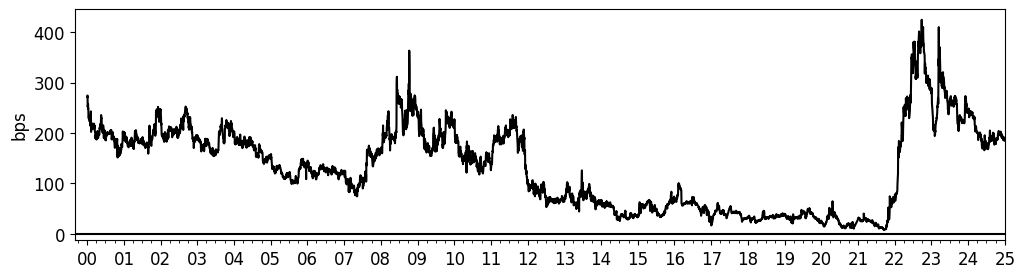

In [7]:
month = mdates.MonthLocator(range(1,13,3)) 
year = mdates.YearLocator()

fig,ax = plt.subplots(1,1,figsize=(12,3))
ax.plot(indicator.index,indicator.pdf_width,color='k')
ax.axhline(0,color='black')
ax.xaxis.set_major_locator(year)
ax.xaxis.set_minor_locator(month)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.set_xlim([datetime(1999,9,1),datetime(2025,1,1)])
#ax.set_title('Option Implied PDF: 90th-10th Percentile. EURONEXT. 12-month')
ax.set_ylabel('bps')
plt.savefig(r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Output\Uncertainty.png',dpi=200,bbox_inches='tight')

In [ ]:
indicator.to_excel('Uncertainty_Indicator_1090_12month.xlsx')